In [2]:
from google.colab import files
import pandas as pd

# Upload CSV
uploaded = files.upload()

# Get the uploaded filename automatically
filename = next(iter(uploaded))

# Read CSV
df = pd.read_csv(filename)

print("File loaded successfully!")
print("Filename:", filename)
print("Dataset shape:", df.shape)

display(df.head())

Saving placement_predict_50k_adjusted (1)  - A.csv to placement_predict_50k_adjusted (1)  - A (1).csv
File loaded successfully!
Filename: placement_predict_50k_adjusted (1)  - A (1).csv
Dataset shape: (50000, 21)


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NUMERIC_COLS = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

CATEGORICAL_COLS = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "ExtraCurricular"
]

print("=" * 70)
print("PLACEMENTPREDICT STUDENT CLUSTERING")
print("K-Means / Hierarchical / DBSCAN")
print("=" * 70)

PLACEMENTPREDICT STUDENT CLUSTERING
K-Means / Hierarchical / DBSCAN


In [4]:
# Handle missing numerical values
imputer = SimpleImputer(strategy="median")

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS,
    index=df.index
)

# Convert categorical columns into numbers
cat_df = pd.get_dummies(
    df[CATEGORICAL_COLS],
    drop_first=True
)

# Combine numerical + categorical features
feature_df = pd.concat(
    [num_df, cat_df],
    axis=1
)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

print(
    f"Loaded {len(df):,} students, "
    f"{feature_df.shape[1]} clustering features "
    f"(PlacementStatus & IsAnomaly excluded)"
)

Loaded 50,000 students, 33 clustering features (PlacementStatus & IsAnomaly excluded)


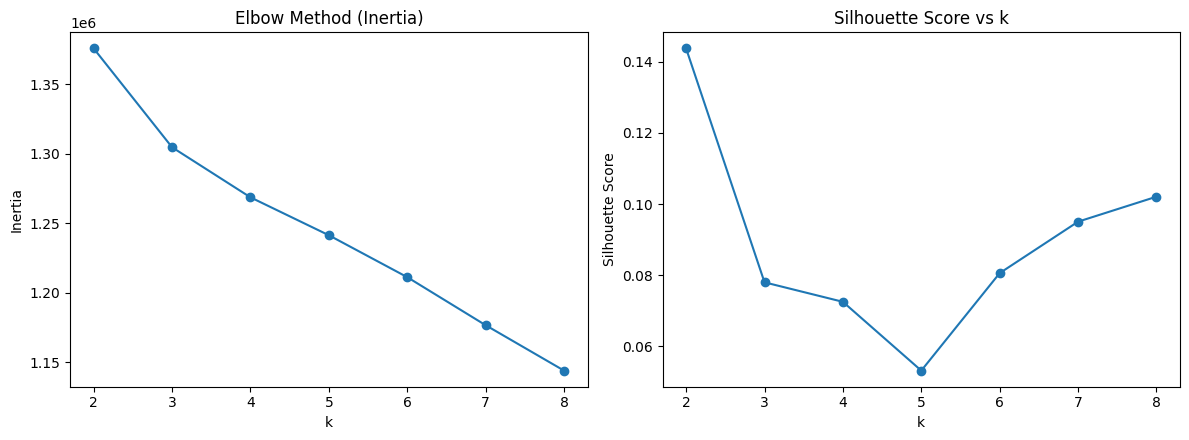

Silhouette-suggested k = 2
Scores: k=2:0.144, k=3:0.078, k=4:0.073, k=5:0.053, k=6:0.081, k=7:0.095, k=8:0.102


In [5]:
k_range = range(2, 9)

# Use 5000 students for silhouette calculation
sil_sample_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    5000,
    replace=False
)

X_sil_sample = X[sil_sample_idx]

inertias = []
sil_scores = []

for k in k_range:

    km_k = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels_k = km_k.fit_predict(X)

    inertias.append(km_k.inertia_)

    sil_scores.append(
        silhouette_score(
            X_sil_sample,
            km_k.predict(X_sil_sample)
        )
    )

# Plot elbow and silhouette
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 4.5)
)

ax1.plot(
    list(k_range),
    inertias,
    marker="o"
)

ax1.set_title("Elbow Method (Inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")

ax2.plot(
    list(k_range),
    sil_scores,
    marker="o"
)

ax2.set_title("Silhouette Score vs k")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[
    int(np.argmax(sil_scores))
]

print(
    f"Silhouette-suggested k = {best_k}"
)

print(
    "Scores:",
    ", ".join(
        f"k={k}:{s:.3f}"
        for k, s in zip(k_range, sil_scores)
    )
)

In [6]:
kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE
)

km_labels = kmeans.fit_predict(X)

sil = silhouette_score(
    X[sil_sample_idx],
    km_labels[sil_sample_idx]
)

print(
    f"\nK-Means (k={best_k}) "
    f"silhouette (5k sample): {sil:.3f}"
)

print(
    "Cluster sizes:",
    pd.Series(km_labels)
    .value_counts()
    .sort_index()
    .to_dict()
)


K-Means (k=2) silhouette (5k sample): 0.144
Cluster sizes: {0: 26429, 1: 23571}


In [7]:
profiled = feature_df.copy()

profiled["KMeansCluster"] = km_labels

# PlacementStatus is used only for reporting
profiled["PlacementStatus"] = df[
    "PlacementStatus"
].values

summary = profiled.groupby(
    "KMeansCluster"
).agg(
    n_students=("PlacementStatus", "size"),
    placement_rate=("PlacementStatus", "mean"),
    avg_CGPA=("CGPA", "mean"),
    avg_AttendancePercent=("AttendancePercent", "mean"),
    avg_AptitudeTestScore=("AptitudeTestScore", "mean"),
    avg_SoftSkillsRating=("SoftSkillsRating", "mean"),
    avg_CodingTestScore=("CodingTestScore", "mean"),
    avg_MockInterviewScore=("MockInterviewScore", "mean"),
    avg_Internships=("Internships", "mean"),
    avg_Projects=("Projects", "mean")
).round(3)

print("\n--- Cluster Profiles ---")
print(summary.to_string())

summary.to_csv(
    "cluster_profiles.csv"
)

print(
    "\nSaved table -> cluster_profiles.csv"
)


--- Cluster Profiles ---
               n_students  placement_rate  avg_CGPA  avg_AttendancePercent  avg_AptitudeTestScore  avg_SoftSkillsRating  avg_CodingTestScore  avg_MockInterviewScore  avg_Internships  avg_Projects
KMeansCluster                                                                                                                                                                                      
0                   26429           0.202     6.558                 67.338                 54.559                 5.444               47.260                  54.743            0.621         1.556
1                   23571           0.781     8.131                 83.340                 76.411                 7.658               74.035                  76.239            1.978         3.628

Saved table -> cluster_profiles.csv


In [8]:
# Use 5000 students because these methods are computationally expensive
sub_idx = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X),
    5000,
    replace=False
)

X_sub = X[sub_idx]

# -----------------------------
# Hierarchical Clustering
# -----------------------------

hc = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hc_labels = hc.fit_predict(X_sub)

sil_hc = silhouette_score(
    X_sub,
    hc_labels
)

print(
    f"\nHierarchical "
    f"(k={best_k}, subsample n=5000) "
    f"silhouette: {sil_hc:.3f}"
)

# -----------------------------
# DBSCAN
# -----------------------------

db = DBSCAN(
    eps=4.0,
    min_samples=15
)

db_labels = db.fit_predict(X_sub)

n_db_clusters = (
    len(set(db_labels))
    - (1 if -1 in db_labels else 0)
)

n_noise = int(
    np.sum(db_labels == -1)
)

print(
    f"DBSCAN (subsample n=5000): "
    f"{n_db_clusters} clusters, "
    f"{n_noise} noise points"
)

if n_db_clusters >= 2:

    mask = db_labels != -1

    db_sil = silhouette_score(
        X_sub[mask],
        db_labels[mask]
    )

    print(
        f"DBSCAN silhouette "
        f"(excluding noise): {db_sil:.3f}"
    )


Hierarchical (k=2, subsample n=5000) silhouette: 0.114
DBSCAN (subsample n=5000): 6 clusters, 2083 noise points
DBSCAN silhouette (excluding noise): -0.064


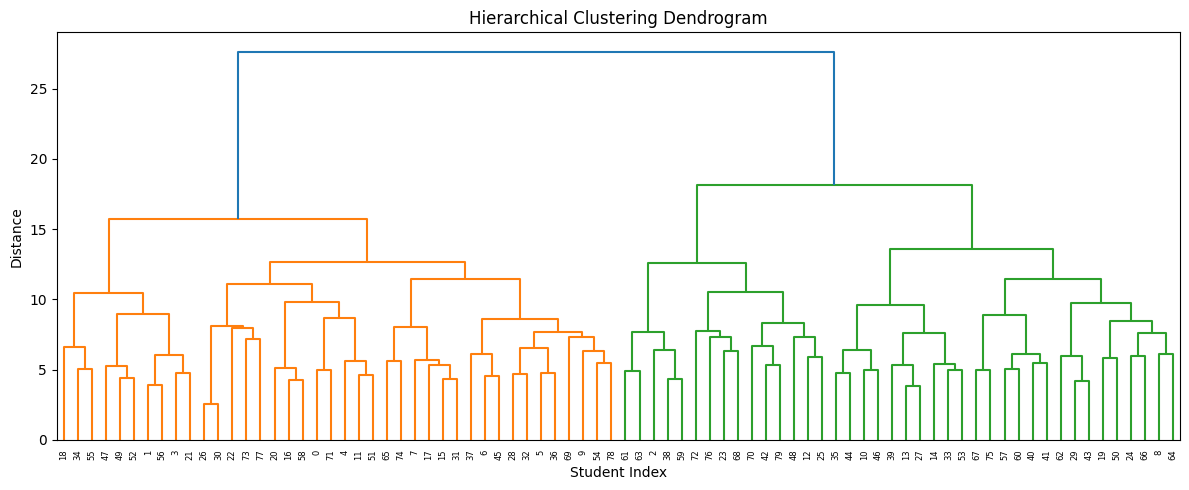

In [9]:
# Select a small sample for readable dendrogram
dendro_idx = np.random.choice(
    len(X_sub),
    size=min(80, len(X_sub)),
    replace=False
)

Z = linkage(
    X_sub[dendro_idx],
    method="ward"
)

plt.figure(
    figsize=(12, 5)
)

dendrogram(Z)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Student Index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

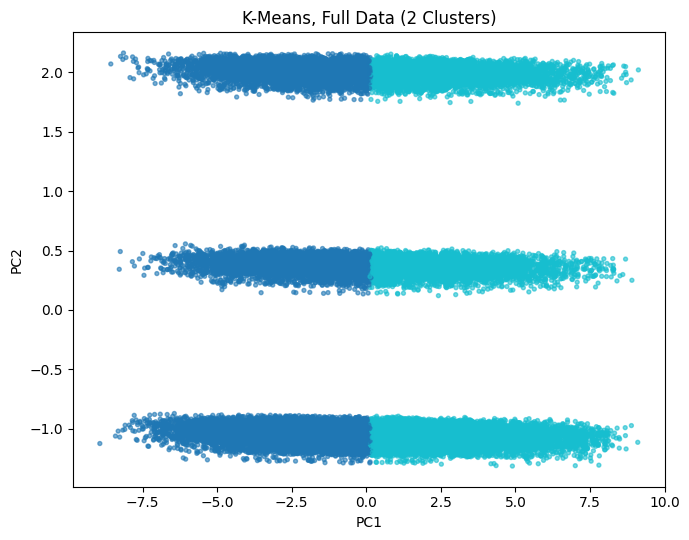

In [10]:
# Reduce full dataset to 2 principal components
X_pca_full = PCA(
    n_components=2,
    random_state=RANDOM_STATE
).fit_transform(X)

# -----------------------------
# K-Means PCA plot
# -----------------------------

plt.figure(
    figsize=(7, 5.5)
)

plt.scatter(
    X_pca_full[:, 0],
    X_pca_full[:, 1],
    c=km_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.title(
    f"K-Means, Full Data ({best_k} Clusters)"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

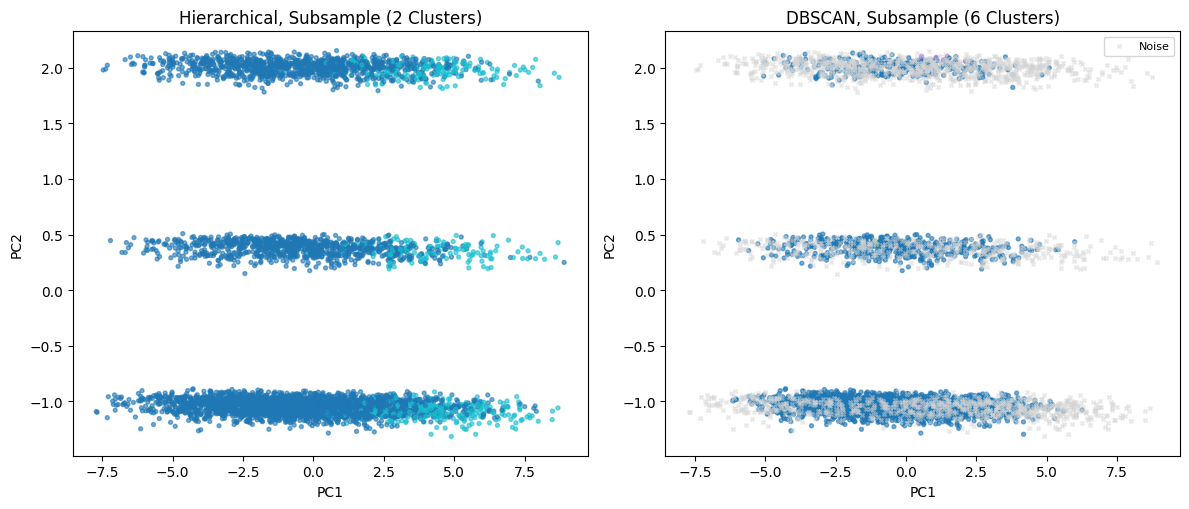

In [13]:
coords_sub = X_pca_full[sub_idx]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2)
)

# -----------------------------
# Hierarchical
# -----------------------------

axes[0].scatter(
    coords_sub[:, 0],
    coords_sub[:, 1],
    c=hc_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

axes[0].set_title(
    f"Hierarchical, Subsample ({best_k} Clusters)"
)

# -----------------------------
# DBSCAN
# -----------------------------

noise_mask = db_labels == -1

axes[1].scatter(
    coords_sub[~noise_mask, 0],
    coords_sub[~noise_mask, 1],
    c=db_labels[~noise_mask],
    cmap="tab10",
    s=8,
    alpha=0.6
)

axes[1].scatter(
    coords_sub[noise_mask, 0],
    coords_sub[noise_mask, 1],
    c="lightgray",
    s=8,
    alpha=0.5,
    marker="x",
    label="Noise"
)

axes[1].legend(
    loc="upper right",
    fontsize=8
)

axes[1].set_title(
    f"DBSCAN, Subsample ({n_db_clusters} Clusters)"
)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [12]:
df_out = df.copy()

df_out["KMeansCluster"] = km_labels

df_out.to_csv(
    "placement_predict_with_clusters.csv",
    index=False
)

print(
    "\nSaved deliverable -> "
    "placement_predict_with_clusters.csv"
)

print(
    "(Original data + KMeansCluster column)"
)


Saved deliverable -> placement_predict_with_clusters.csv
(Original data + KMeansCluster column)


In [11]:
print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print("K-Means clustering completed.")
print("Hierarchical clustering completed.")
print("DBSCAN completed.")
print("Dendrogram generated.")
print("PCA visualizations generated.")
print("Final clustered CSV created.")


DONE
K-Means clustering completed.
Hierarchical clustering completed.
DBSCAN completed.
Dendrogram generated.
PCA visualizations generated.
Final clustered CSV created.
